In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_predict
from sklearn.metrics import confusion_matrix,accuracy_score,mean_squared_error,r2_score,roc_auc_score,roc_curve,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.simplefilter(action='ignore')
sns.set()
plt.style.use("ggplot")
%matplotlib inline

In [5]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
# percentage of outcomes
# distribution of outcome
df["Outcome"].value_counts()*100/len(df)

Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

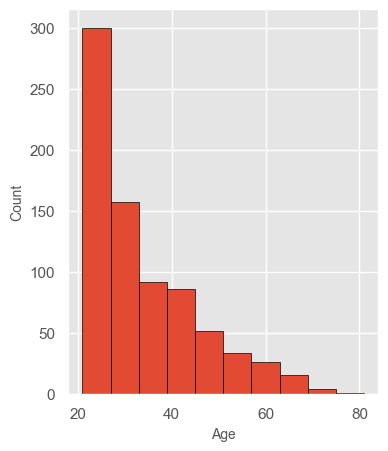

In [12]:
#plot hist of age
plt.figure(figsize=(4,5))
plt.xlabel('Age',fontsize=10)
plt.ylabel('Count',fontsize=10)
df['Age'].hist(edgecolor='black')

In [13]:
print("MAX AGE: "+str(df['Age'].max()) )
print("MIN AGE: "+str(df['Age'].min()))

MAX AGE: 81
MIN AGE: 21


In [14]:
#Density graph
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

<Axes: xlabel='Age', ylabel='Density'>

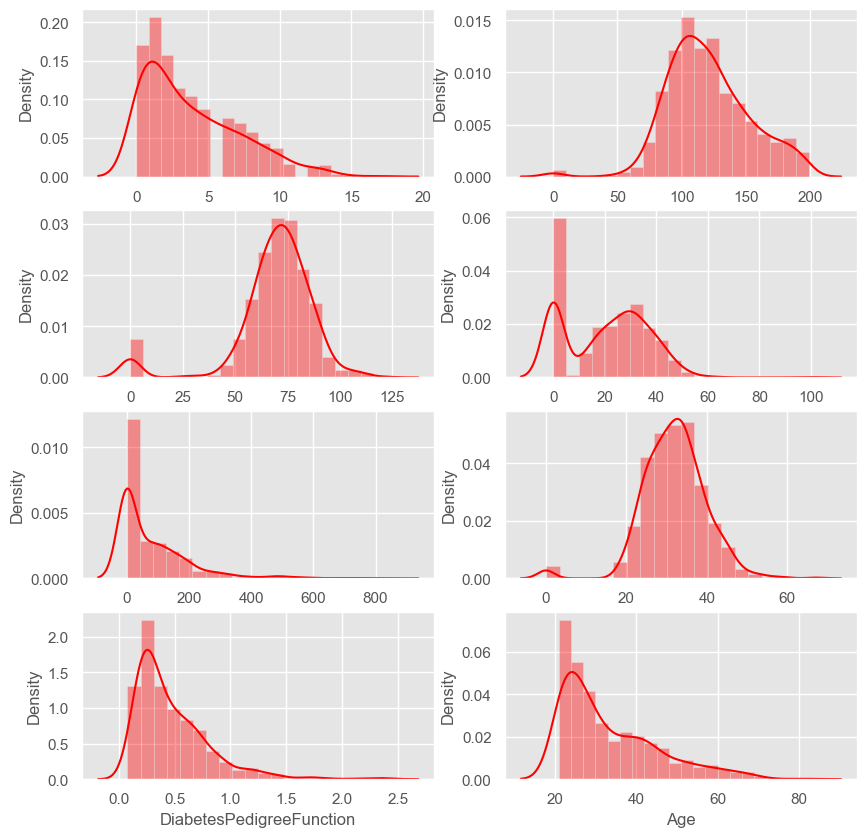

In [21]:
fig,ax=plt.subplots(4,2,figsize=(10,10))
sns.distplot(df.Pregnancies,bins=20,ax=ax[0,0],color="red")
sns.distplot(df.Glucose,bins=20,ax=ax[0,1],color="red")
sns.distplot(df.BloodPressure,bins=20,ax=ax[1,0],color="red")
sns.distplot(df.SkinThickness,bins=20,ax=ax[1,1],color="red")
sns.distplot(df.Insulin,bins=20,ax=ax[2,0],color="red")
sns.distplot(df.BMI,bins=20,ax=ax[2,1],color="red")
sns.distplot(df.DiabetesPedigreeFunction,bins=20,ax=ax[3,0],color="red")
sns.distplot(df.Age,bins=20,ax=ax[3,1],color="red")

In [22]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [30]:
cols = [
    "Pregnancies", "Glucose",
    "BloodPressure", "SkinThickness",
    "Insulin", "BMI",
    "DiabetesPedigreeFunction", "Age"
]

for i in range(0, len(cols), 2):
    print(df.groupby("Outcome").agg({
        cols[i]: ["mean", "min", "max"],
        cols[i+1]: ["mean", "min", "max"]
    }))
    print("-" * 60)

        Pregnancies             Glucose         
               mean min max        mean min  max
Outcome                                         
0          3.298000   0  13  109.980000   0  197
1          4.865672   0  17  141.257463   0  199
------------------------------------------------------------
        BloodPressure          SkinThickness        
                 mean min  max          mean min max
Outcome                                             
0           68.184000   0  122     19.664000   0  60
1           70.824627   0  114     22.164179   0  99
------------------------------------------------------------
            Insulin                 BMI           
               mean min  max       mean  min   max
Outcome                                           
0         68.792000   0  744  30.304200  0.0  57.3
1        100.335821   0  846  35.142537  0.0  67.1
------------------------------------------------------------
        DiabetesPedigreeFunction                    

In [ ]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


Text(0.5, 1.0, 'Correlation Matix')

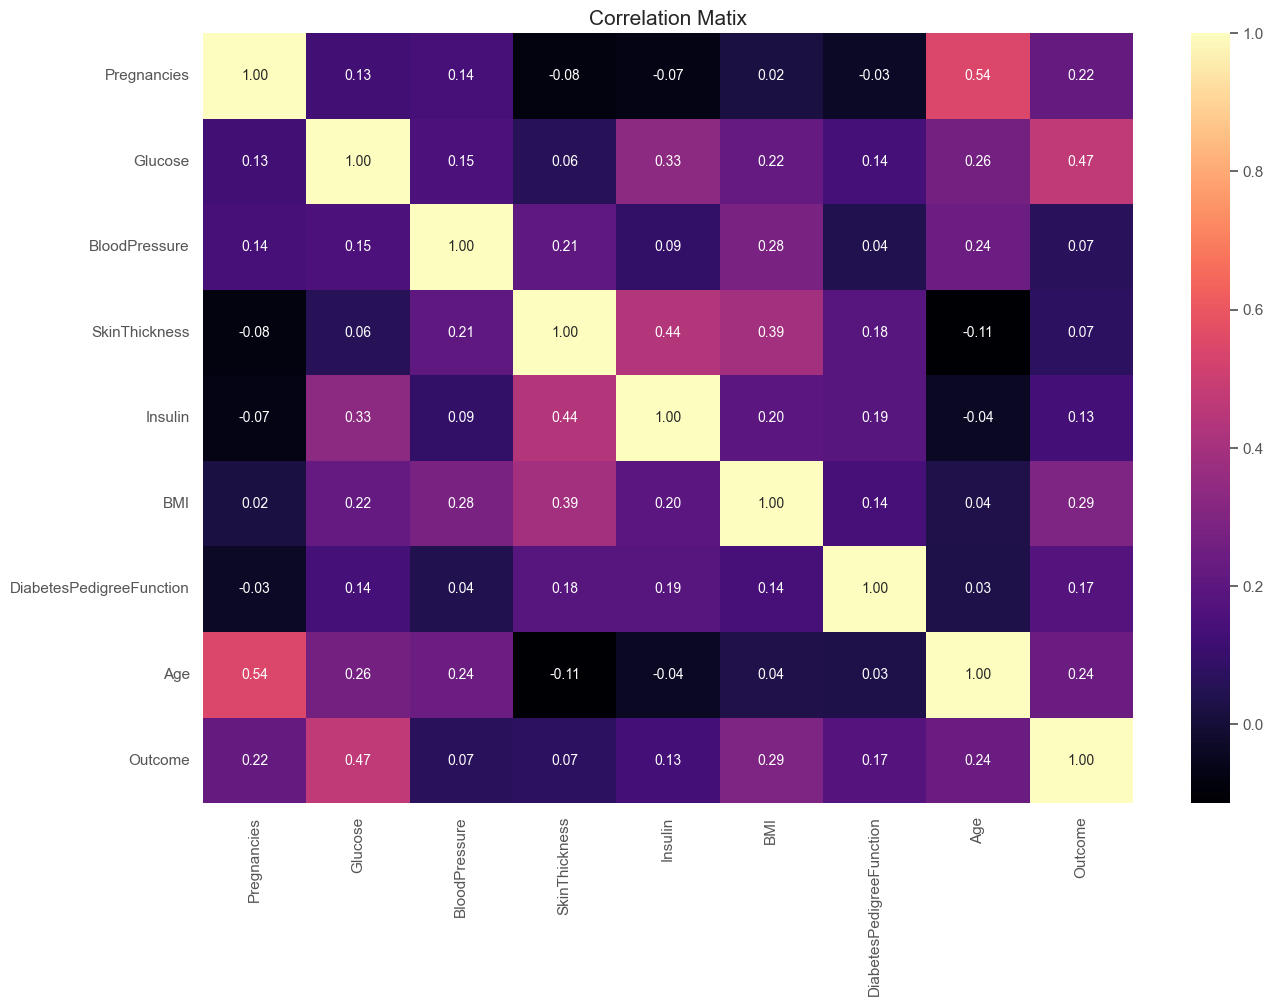

In [ ]:
#EDA FINAL PART
f,ax=plt.subplots(figsize=[15,10])
sns.heatmap(df.corr(),annot=True,fmt='.2f',ax=ax,cmap='magma')
ax.set_title("Correlation Matix",fontsize=15)


In [48]:
#DATA PREPROCESSING
df = pd.read_csv("diabetes.csv")

In [ ]:
#REPLACE 0 with NAN
cols = [
    'Pregnancies', 'Glucose', 'BloodPressure',
    'SkinThickness', 'Insulin', 'BMI',
    'DiabetesPedigreeFunction', 'Age'
]

df[cols] = df[cols].replace(0, np.nan)

In [51]:
df.isnull().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [52]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,NaN,137.0,40.0,35.0,168.0,43.1,2.288,33,1


<Axes: >

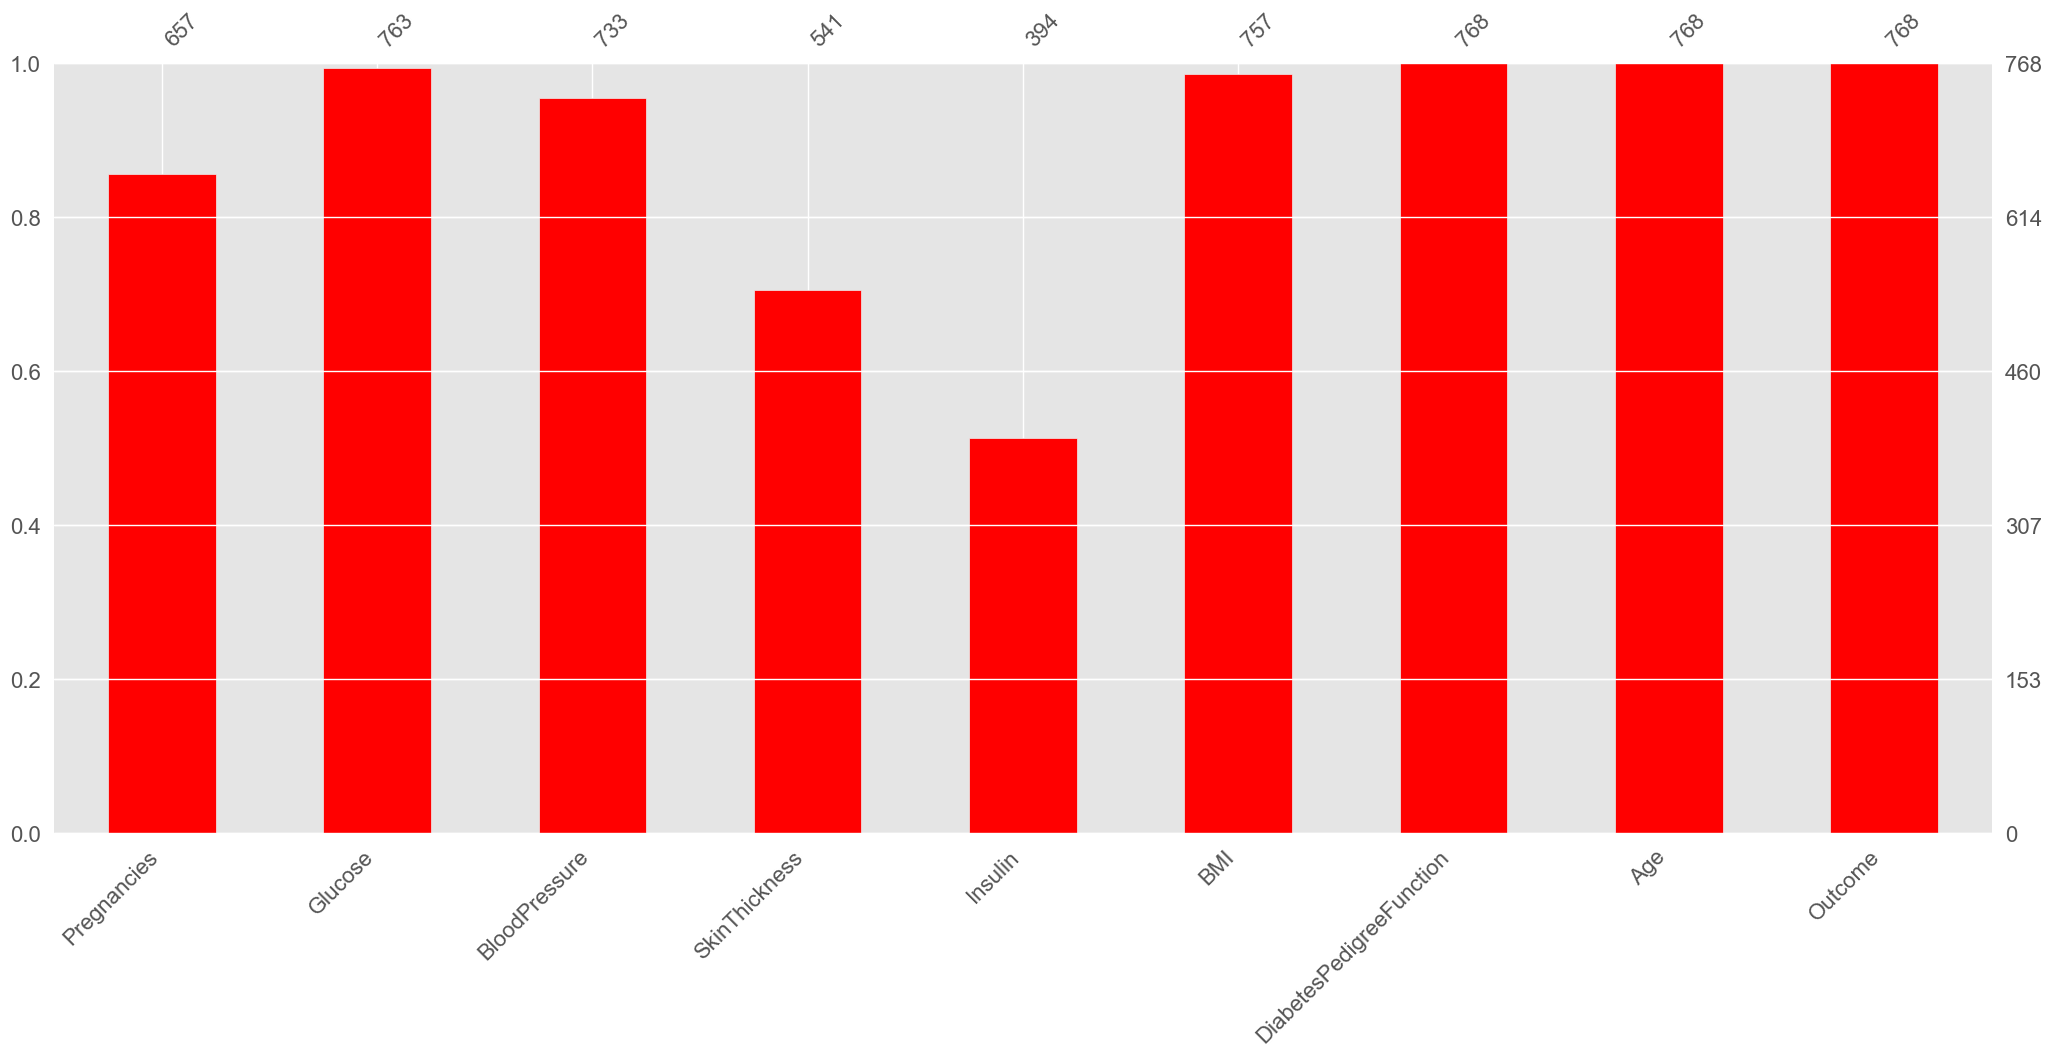

In [55]:
import missingno as ms

ms.bar(df, color="red")
